In [2]:
import h5py
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import keras
import keras.backend as K
import tensorflow.keras as tk
from keras.layers import LeakyReLU
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [15]:
dataset_file = h5py.File('archive/GOLD_XYZ_OSC.0001_1024.hdf5','r+')
dataset_file

<HDF5 file "GOLD_XYZ_OSC.0001_1024.hdf5" (mode r+)>

In [19]:
def explore_hdf5_contents(file):
    """
    Explore and print the structure of an HDF5 file.
    
    Parameters:
    - file: Opened HDF5 file object
    """
    def print_attrs(name, obj):
        print(f"Name: {name}")
        print(f"  Type: {type(obj)}")
        
        # Print attributes if any
        if hasattr(obj, 'attrs'):
            print("  Attributes:")
            for key, value in obj.attrs.items():
                print(f"    {key}: {value}")
        
        # If it's a dataset, print some basic info
        if isinstance(obj, h5py.Dataset):
            print(f"  Shape: {obj.shape}")
            print(f"  Dtype: {obj.dtype}")
        
        print()

    file.visititems(print_attrs)

In [23]:
filename = 'archive/GOLD_XYZ_OSC.0001_1024.hdf5'
    
with h5py.File(filename, 'r') as file:
    print("File Contents:")
    explore_hdf5_contents(file)

File Contents:
Name: X
  Type: <class 'h5py._hl.dataset.Dataset'>
  Attributes:
  Shape: (2555904, 1024, 2)
  Dtype: float32

Name: Y
  Type: <class 'h5py._hl.dataset.Dataset'>
  Attributes:
  Shape: (2555904, 24)
  Dtype: int64

Name: Z
  Type: <class 'h5py._hl.dataset.Dataset'>
  Attributes:
  Shape: (2555904, 1)
  Dtype: int64



In [25]:
wanted_mods = ["QPSK","16QAM"]

In [27]:
base_modulation_clases = ['OOK',

 '4ASK',

 '8ASK',

 'BPSK',

 'QPSK',

 '8PSK',

 '16PSK',

 '32PSK',

 '16APSK',

 '32APSK',

 '64APSK',

 '128APSK',

 '16QAM',

 '32QAM',

 '64QAM',

 '128QAM',

 '256QAM',

 'AM-SSB-WC',

 'AM-SSB-SC',

 'AM-DSB-WC',

 'AM-DSB-SC',

 'FM',

 'GMSK',

 'OQPSK']



selected_modulation_classes = ['QPSK', '16QAM',]


selected_classes_id = list()

for selected_class in selected_modulation_classes:

    for id, base_class in enumerate(base_modulation_clases):

        if selected_class == base_class:

            selected_classes_id.append(id)

selected_classes_id

[4, 12]

In [29]:
N_SNR = 4 # from 30 SNR to 22 SNR

X_data = list()
y_data = list()

for id in selected_classes_id:
    if len(X_data) != 0:
        X_data = np.concatenate([X_data, dataset_file['X'][(106496*(id+1) - 4096*N_SNR):106496*(id+1)]])
        y_data = np.concatenate([y_data, dataset_file['Y'][(106496*(id+1) - 4096*N_SNR):106496*(id+1)]])
    else:
        X_data = (dataset_file['X'][(106496*(id+1) - 4096*N_SNR):106496*(id+1)])
        y_data = (dataset_file['Y'][(106496*(id+1) - 4096*N_SNR):106496*(id+1)])

In [31]:
X_data = X_data.reshape(len(X_data), 32, 32, 2)
X_data.shape

(32768, 32, 32, 2)

In [33]:
y_data_df = pd.DataFrame(y_data)
for column in y_data_df.columns:
    if sum(y_data_df[column]) == 0:
        y_data_df = y_data_df.drop(columns = [column])
y_data_df.columns = selected_modulation_classes
y_data_df

,QPSK,16QAM
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
32763,0,1
32764,0,1
32765,0,1
32766,0,1


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data_df, test_size = 0.2)

# CNN Model

In [11]:
def create_model():
    learning_rate = 0.0001

    i_input = keras.layers.Input(shape=(32,32,1))
    q_input = keras.layers.Input(shape=(32,32,1))
    
    cnn_q_1 = tk.layers.Conv2D(64, 3, activation = LeakyReLU(alpha = 0.1))(q_input)
    cnn_q_1_2 = tk.layers.Conv2D(64, 3, activation = LeakyReLU(alpha = 0.1))(cnn_q_1)
    pool_q_1 = tk.layers.MaxPool2D(pool_size = 3, strides = 2, padding = 'valid')(cnn_q_1)
    cnn_q_2 = tk.layers.Conv2D(128, 3, activation = LeakyReLU(alpha = 0.1))(pool_q_1)
    cnn_q_2_2 = tk.layers.Conv2D(128, 3, activation = LeakyReLU(alpha = 0.1))(cnn_q_2)
    pool_q_2 = tk.layers.MaxPool2D(pool_size = 3, strides = 2, padding = 'valid')(cnn_q_2_2)
    flatten_q = tk.layers.Flatten()(pool_q_2)

    cnn_i_1 = tk.layers.Conv2D(64, 3, activation = LeakyReLU(alpha = 0.1))(i_input)
    cnn_i_1_2 = tk.layers.Conv2D(64, 3, activation = LeakyReLU(alpha = 0.1))(cnn_i_1)
    pool_i_1 = tk.layers.MaxPool2D(pool_size = 3, strides = 2, padding = 'valid')(cnn_i_1_2)
    cnn_i_2 = tk.layers.Conv2D(128, 3, activation = LeakyReLU(alpha = 0.1))(pool_i_1)
    cnn_i_2_2 = tk.layers.Conv2D(128, 3, activation = LeakyReLU(alpha = 0.1))(cnn_i_2)
    pool_i_2 = tk.layers.MaxPool2D(pool_size = 3, strides = 2, padding = 'valid')(cnn_i_2_2)
    flatten_i = tk.layers.Flatten()(pool_i_2)

    concat = keras.layers.concatenate([flatten_q, flatten_i])
    dense1 = keras.layers.Dense(1024, activation = LeakyReLU(alpha = 0.1))(concat)
    dense2 = keras.layers.Dense(1024, activation = LeakyReLU(alpha = 0.1))(dense1)
    dense3 = keras.layers.Dense(1024, activation = LeakyReLU(alpha = 0.1))(dense2)
    dense4 = keras.layers.Dense(256, activation = LeakyReLU(alpha = 0.1))(dense3)
    dense5 = keras.layers.Dense(32, activation = LeakyReLU(alpha = 0.1))(dense4)
    outputs = keras.layers.Dense(len(selected_classes_id), activation='softmax')(dense5)

    model = keras.Model(inputs=[i_input, q_input], outputs=outputs)
    model.compile(
        loss='categorical_crossentropy', 
        optimizer=tk.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    # model.summary()
    return model

model = create_model()

/home/yaseeng/anaconda3/envs/myenv/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1744304496.044234   12097 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4269 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
batch_size = 64
epochs = 50

path_checkpoint = "model_checkpoint.weights.h5"
# es_callback = tk.callbacks.EarlyStopping(monitor="accuracy", min_delta=0, patience=10)

modelckpt_callback = tk.callbacks.ModelCheckpoint(
    monitor="accuracy",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(

    x = [X_train[:,:,:,0], X_train[:,:,:,1]],
    y = y_train,

    batch_size = batch_size,
    epochs=epochs,
    validation_data=([X_test[:,:,:,0], X_test[:,:,:,1]], y_test),
    callbacks=[modelckpt_callback],
)

Epoch 1/50


I0000 00:00:1744304497.919372   12213 service.cc:148] XLA service 0x71f29c015960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744304497.919397   12213 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-04-10 22:31:37.952638: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744304498.115536   12213 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-10 22:31:38.155711: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
2025-04

 16/410 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4859 - loss: 0.6952 

I0000 00:00:1744304501.446049   12213 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


409/410 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5576 - loss: 0.6644

2025-04-10 22:31:46.285764: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1144', 88 bytes spill stores, 88 bytes spill loads

2025-04-10 22:31:46.325814: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1144', 60 bytes spill stores, 60 bytes spill loads

2025-04-10 22:31:46.328497: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1144', 20 bytes spill stores, 24 bytes spill loads



410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5578 - loss: 0.6642
Epoch 1: accuracy improved from -inf to 0.63294, saving model to model_checkpoint.weights.h5
410/410 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5580 - loss: 0.6641 - val_accuracy: 0.7243 - val_loss: 0.5256
Epoch 2/50
406/410 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7295 - loss: 0.5052
Epoch 2: accuracy improved from 0.63294 to 0.73804, saving model to model_checkpoint.weights.h5
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7296 - loss: 0.5051 - val_accuracy: 0.7418 - val_loss: 0.4660
Epoch 3/50
405/410 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7843 - loss: 0.4258
Epoch 3: accuracy improved from 0.73804 to 0.80144, saving model to model_checkpoint.weights.h5
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7846 - loss: 0.4254 - val_accuracy: 0.7566 - val_loss: 0.4613
Epoch 4/50
409/410 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8527 - loss: 0.3151
Epoch 4: accuracy impro

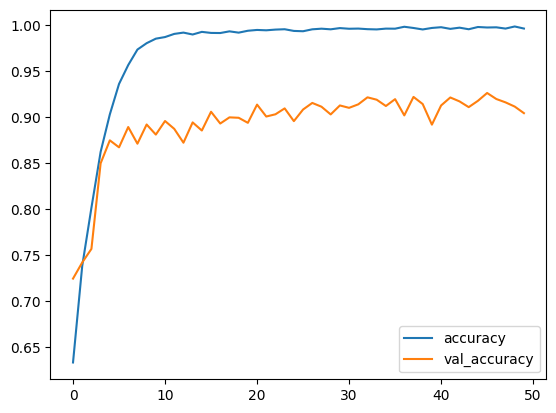

In [14]:
plt.plot(np.c_[history.history['accuracy'],history.history['val_accuracy']])
plt.legend(['accuracy', 'val_accuracy'])

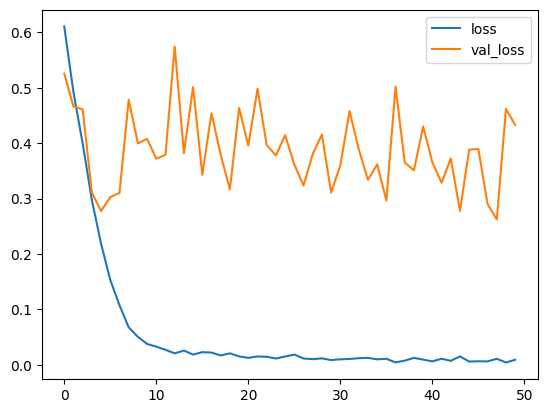

In [15]:
plt.plot(np.c_[history.history['loss'],history.history['val_loss']])
plt.legend(['loss', 'val_loss'])

In [16]:
model_predictions = model.predict([X_test[:,:,:,0], X_test[:,:,:,1]])
model_predictions

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step    


array([[3.12367831e-07, 9.99999642e-01],
       [4.40907687e-01, 5.59092283e-01],
       [1.19112825e-04, 9.99880910e-01],
       ...,
       [6.07617358e-06, 9.99993920e-01],
       [3.49315614e-01, 6.50684357e-01],
       [1.00000000e+00, 2.48937777e-08]], dtype=float32)

In [17]:
def convert_to_matrix(logit_list):
    logit_list = list(logit_list)
    return logit_list.index(max(logit_list))

cm = confusion_matrix(
    y_true = list(map(convert_to_matrix , y_test.values)),
    y_pred = list(map(convert_to_matrix , model_predictions)),
)

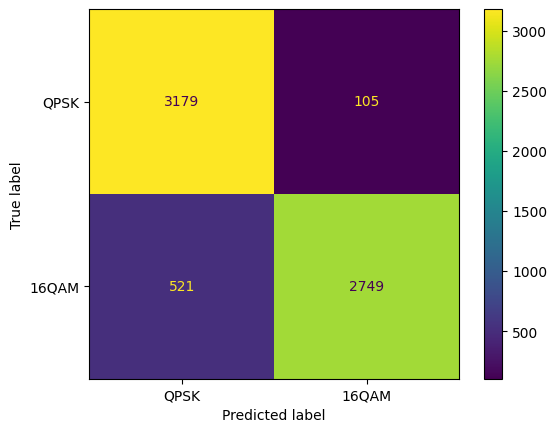

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=selected_modulation_classes)
disp.plot()
plt.show()

In [19]:
loss, acc = model.evaluate([X_test[:,:,:,0], X_test[:,:,:,1]], y_test, verbose=2)
print("Restored model, accuracy: {:5.2f}%".format(100 * acc))

205/205 - 1s - 3ms/step - accuracy: 0.9045 - loss: 0.4330
Restored model, accuracy: 90.45%


# LSTM Model

In [28]:
from tensorflow import keras
from keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, LeakyReLU, concatenate, BatchNormalization
from keras.regularizers import l2
import tensorflow.keras as tk

def create_lstm_model():
    learning_rate = 0.0003  # Slightly increased LR
    l2_reg = 1e-4
    dropout_rate = 0.3

    i_input = Input(shape=(32, 32))  # (timesteps, features)
    q_input = Input(shape=(32, 32))

    # Bi-LSTM branch for q_input
    q_lstm = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(l2_reg)))(q_input)
    q_lstm = Bidirectional(LSTM(64, kernel_regularizer=l2(l2_reg)))(q_lstm)
    q_lstm = BatchNormalization()(q_lstm)
    q_lstm = Dropout(dropout_rate)(q_lstm)

    # Bi-LSTM branch for i_input
    i_lstm = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(l2_reg)))(i_input)
    i_lstm = Bidirectional(LSTM(64, kernel_regularizer=l2(l2_reg)))(i_lstm)
    i_lstm = BatchNormalization()(i_lstm)
    i_lstm = Dropout(dropout_rate)(i_lstm)

    # Merge both
    merged = concatenate([q_lstm, i_lstm])

    # Fully connected layers
    x = Dense(512, kernel_regularizer=l2(l2_reg))(merged)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(256, kernel_regularizer=l2(l2_reg))(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, kernel_regularizer=l2(l2_reg))(x)
    x = LeakyReLU(alpha=0.1)(x)

    outputs = Dense(len(selected_classes_id), activation='softmax')(x)

    model = keras.Model(inputs=[i_input, q_input], outputs=outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tk.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    return model

model = create_lstm_model()


/home/yaseeng/anaconda3/envs/myenv/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [29]:
batch_size = 64
epochs = 50

path_checkpoint = "model_checkpoint.weights.h5"
# es_callback = tk.callbacks.EarlyStopping(monitor="accuracy", min_delta=0, patience=10)

modelckpt_callback = tk.callbacks.ModelCheckpoint(
    monitor="accuracy",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(

    x = [X_train[:,:,:,0], X_train[:,:,:,1]],
    y = y_train,

    batch_size = batch_size,
    epochs=epochs,
    validation_data=([X_test[:,:,:,0], X_test[:,:,:,1]], y_test),
    callbacks=[modelckpt_callback],
)

Epoch 1/50
408/410 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5027 - loss: 0.8974
Epoch 1: accuracy improved from -inf to 0.49859, saving model to model_checkpoint.weights.h5
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5027 - loss: 0.8973 - val_accuracy: 0.4945 - val_loss: 0.8451
Epoch 2/50
407/410 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5058 - loss: 0.8426
Epoch 2: accuracy improved from 0.49859 to 0.50340, saving model to model_checkpoint.weights.h5
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5058 - loss: 0.8425 - val_accuracy: 0.5006 - val_loss: 0.8266
Epoch 3/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5076 - loss: 0.8231
Epoch 3: accuracy improved from 0.50340 to 0.50671, saving model to model_checkpoint.weights.h5
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5076 - loss: 0.8230 - val_accuracy: 0.5058 - val_loss: 0.8099
Epoch 4/50
408/410 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5205 - loss: 0.8063
Epoch 4: accu

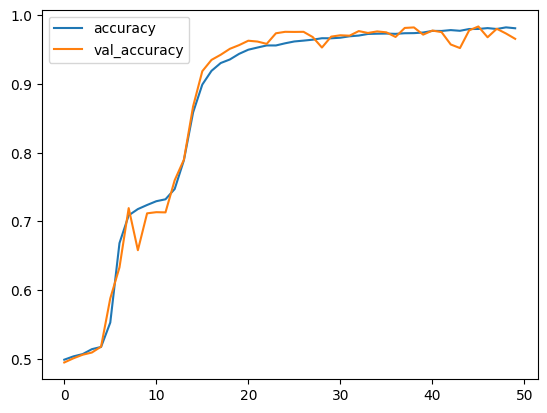

In [30]:
plt.plot(np.c_[history.history['accuracy'],history.history['val_accuracy']])
plt.legend(['accuracy', 'val_accuracy'])


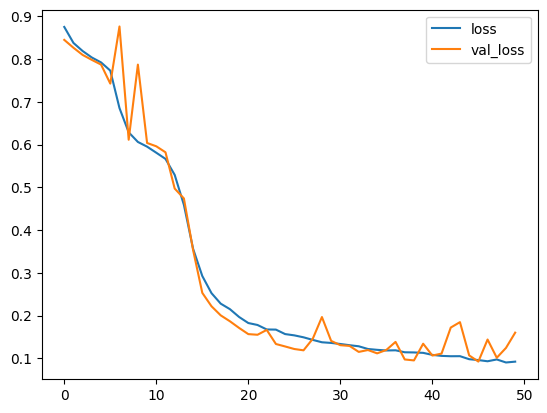

In [31]:
plt.plot(np.c_[history.history['loss'],history.history['val_loss']])
plt.legend(['loss', 'val_loss'])

In [32]:
model_predictions = model.predict([X_test[:,:,:,0], X_test[:,:,:,1]])
model_predictions

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step   


array([[1.2989672e-03, 9.9870098e-01],
       [3.5046364e-04, 9.9964952e-01],
       [3.0514818e-01, 6.9485188e-01],
       ...,
       [5.8618647e-21, 1.0000000e+00],
       [8.5399088e-06, 9.9999142e-01],
       [9.9999905e-01, 9.8252281e-07]], dtype=float32)

In [33]:
def convert_to_matrix(logit_list):
    logit_list = list(logit_list)
    return logit_list.index(max(logit_list))

cm = confusion_matrix(
    y_true = list(map(convert_to_matrix , y_test.values)),
    y_pred = list(map(convert_to_matrix , model_predictions)),
)

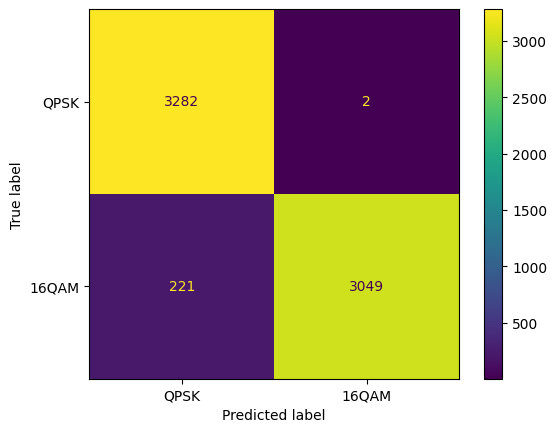

In [34]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=selected_modulation_classes)
disp.plot()
plt.show()

In [35]:
loss, acc = model.evaluate([X_test[:,:,:,0], X_test[:,:,:,1]], y_test, verbose=2)
print("Restored model, accuracy: {:5.2f}%".format(100 * acc))

205/205 - 1s - 5ms/step - accuracy: 0.9660 - loss: 0.1603
Restored model, accuracy: 96.60%
